# Spherical Quantum Well — `quantum_well.py`

This notebook demonstrates every public function in `plytrons.quantum_well`.

The spherical quantum-well model treats the nanoparticle as an infinite potential well of radius $a$. The bound states $(n, \ell)$ are the single-particle levels whose wavefunctions enter the hot-carrier matrix element in `hot_carriers.py`.

| Function | What it does |
|---|---|
| `get_bound_states(a)` | Find all $E_{n,\ell}$ from the characteristic equation |
| `get_normalization(a, E)` | Compute $A_{n,\ell}$ so $\int_0^a |A j_\ell(k_{n\ell} r)|^2 r^2\,dr = 1$ |
| `e_state_assembly(E, A)` | Pack into a `list[QWLevelSet]` used by `hot_e_dist` |
| `electrons_per_nanoparticle(D, N_uc, a_lat)` | Estimate $N_e$ from geometry |
| `fill_qw_states_by_energy(E, D, ...)` | Fill levels in energy order up to $N_e$ |
| `occupation_fraction(occ)` | Convert absolute occupations to $f \in [0,1]$ |
| `compute_qw_states(a)` | Convenience wrapper (steps 1–3 with progress bar) |
| `compute_qw_states_with_occupations(a, D, ...)` | Full pipeline including Fermi filling |

## Step 0 — Imports

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

import plytrons.quantum_well as qw
from plytrons.quantum_well import (
    get_bound_states,
    get_normalization,
    e_state_assembly,
    electrons_per_nanoparticle,
    fill_qw_states_by_energy,
    occupation_fraction,
    compute_qw_states,
    compute_qw_states_with_occupations,
    ke,
)
from plytrons.math_utils import js_real

from numba.core.errors import NumbaTypeSafetyWarning
warnings.simplefilter('ignore', category=NumbaTypeSafetyWarning)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

---
## Step 1 — Bound states of a silver nanosphere

Silver parameters used throughout this notebook:

| Quantity | Value |
|---|---|
| Diameter $D$ | 5 nm |
| Fermi energy $E_F$ | 5.5 eV |
| fcc unit cell | $N_{\rm uc} = 4$ atoms, $a_{\rm lat} = 0.4085$ nm |

`get_bound_states(a)` solves the characteristic equation
$$j_\ell(k_{n\ell}\,a) = 0$$
on a coarse energy grid and refines each root with bisection.  
The result is a padded 2-D array $E[\ell, n]$ with NaN for missing levels.

In [8]:
D    = 5.0     # sphere diameter [nm]
a    = D / 2   # sphere radius   [nm]
EF   = 5.6     # Fermi energy of silver [eV]

E_matrix = get_bound_states(a)
A_matrix = get_normalization(a, E_matrix)
e_states = e_state_assembly(E_matrix, A_matrix)

lmax_qw = len(e_states)
N_total  = sum(e_states[l].Eb.size for l in range(lmax_qw))

print(f'Sphere radius : {a} nm')
print(f'lmax found    : {lmax_qw - 1}')
print(f'Total (n, l) levels: {N_total}')
print()
print(f"{'l':>4}  {'n_levels':>8}  {'E_min (eV)':>12}  {'E_max (eV)':>12}")
print('-' * 44)
for l in range(lmax_qw):
    Eb = e_states[l].Eb
    if Eb.size:
        print(f'{l:>4}  {Eb.size:>8}  {float(Eb[0]):>12.3f}  {float(Eb[-1]):>12.3f}')

Sphere radius : 2.5 nm
lmax found    : 42
Total (n, l) levels: 296

   l  n_levels    E_min (eV)    E_max (eV)
--------------------------------------------
   0        15         0.060        13.536
   1        15         0.123        14.441
   2        14         0.202        13.500
   3        14         0.298        14.380
   4        13         0.408        13.414
   5        13         0.534        14.270
   6        12         0.674        13.279
   7        12         0.828        14.110
   8        12         0.997        14.958
   9        11         1.180        13.898
  10        11         1.378        14.721
  11        10         1.589        13.633
  12        10         1.814        14.429
  13         9         2.053        13.313
  14         9         2.305        14.082
  15         9         2.572        14.867
  16         8         2.852        13.675
  17         8         3.145        14.432
  18         7         3.452        13.204
  19         7         3.77

---
## Step 2 — Energy-level diagram

Each dot is one $(n, \ell)$ level. The degeneracy is $g_{n\ell} = 2(2\ell+1)$  
(spin × magnetic sub-levels), so higher-$\ell$ levels hold more electrons.  
The horizontal dashed line marks the Fermi energy $E_F$.

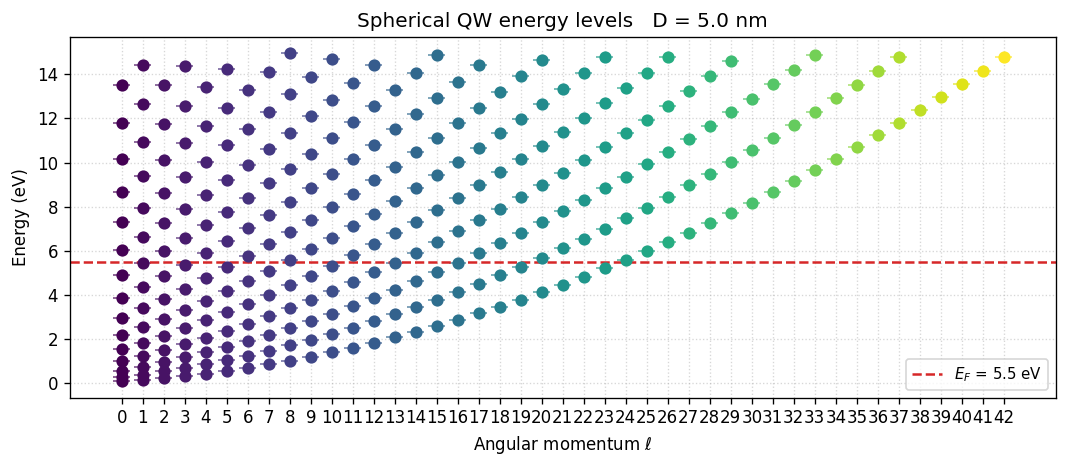

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))

for l in range(lmax_qw):
    Eb = e_states[l].Eb.real
    col = plt.cm.viridis(l / max(lmax_qw - 1, 1))
    ax.scatter(np.full(Eb.size, l), Eb, s=40, color=col, zorder=3)
    for E in Eb:
        ax.plot([l - 0.35, l + 0.35], [E, E], lw=1.2, color=col, alpha=0.6)

ax.axhline(EF, ls='--', lw=1.5, color='C3', label=f'$E_F$ = {EF} eV')
ax.set_xlabel(r'Angular momentum $\ell$')
ax.set_ylabel('Energy (eV)')
ax.set_title(f'Spherical QW energy levels   D = {D} nm')
ax.set_xticks(range(lmax_qw))
ax.legend(fontsize=9)
ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Step 3 — Radial wavefunctions

The normalised radial wavefunction inside the well is

$$\psi_{n\ell}(r) = A_{n\ell}\, j_\ell(k_{n\ell}\,r)$$

High-$\ell$ states (centrifugal barrier) are suppressed near $r = 0$  
and peak close to the surface $r = a$.  
This is why high-$\ell$ states dominate the **surface-peaked** hot-carrier profile.

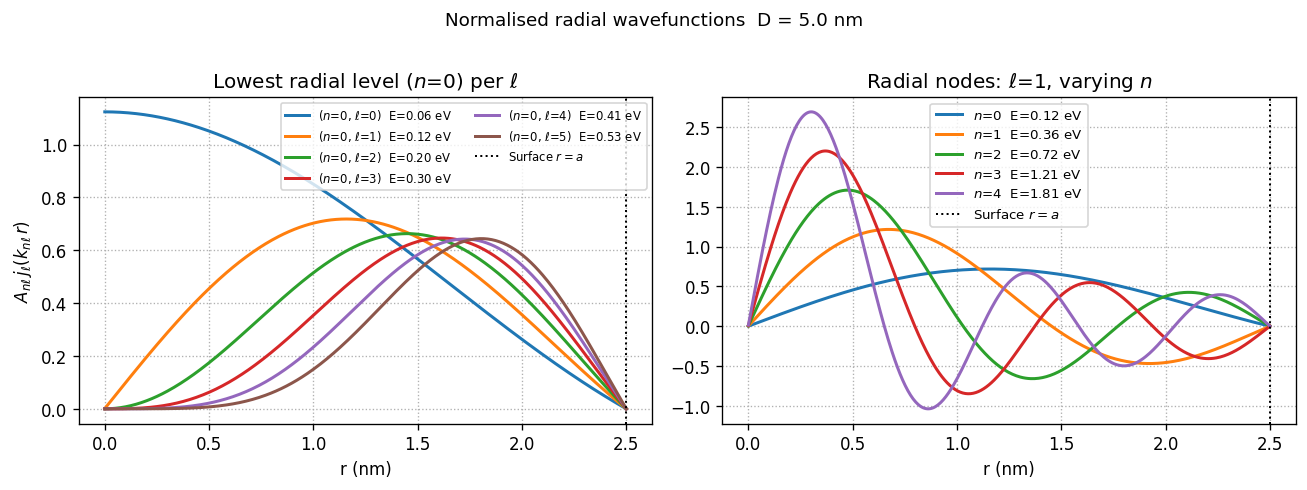

In [4]:
r = np.linspace(1e-3, a, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: lowest n per l ──────────────────────────────────────────────────
ax = axes[0]
for l in range(min(lmax_qw, 6)):
    Eb = e_states[l].Eb
    A  = e_states[l].A
    if Eb.size == 0:
        continue
    psi = float(A[0].real) * js_real(l, float(ke(float(Eb[0]))) * r)
    ax.plot(r, psi, lw=1.8, label=f'($n$=0, $\\ell$={l})  E={float(Eb[0]):.2f} eV')
ax.axvline(a, ls=':', lw=1.2, color='k', label='Surface $r=a$')
ax.set_xlabel('r (nm)')
ax.set_ylabel(r'$A_{n\ell}\,j_\ell(k_{n\ell}\,r)$')
ax.set_title(r'Lowest radial level ($n$=0) per $\ell$')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, ls=':')

# ── Right: several n, fixed l=1 ───────────────────────────────────────────
ax = axes[1]
l_plot = 1
Eb = e_states[l_plot].Eb
A  = e_states[l_plot].A
for n in range(min(Eb.size, 5)):
    psi = float(A[n].real) * js_real(l_plot, float(ke(float(Eb[n]))) * r)
    ax.plot(r, psi, lw=1.8, label=f'$n$={n}  E={float(Eb[n]):.2f} eV')
ax.axvline(a, ls=':', lw=1.2, color='k', label='Surface $r=a$')
ax.set_xlabel('r (nm)')
ax.set_title(f'Radial nodes: $\\ell$={l_plot}, varying $n$')
ax.legend(fontsize=8)
ax.grid(True, ls=':')

fig.suptitle(f'Normalised radial wavefunctions  D = {D} nm', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 4 — Fermi filling

Silver is fcc with 4 atoms per unit cell and lattice constant 0.4085 nm.  
`electrons_per_nanoparticle` estimates the number of conduction electrons  
$N_e = \lfloor N_{\rm uc}\, V_{\rm NP} / V_{\rm uc} \rfloor$.

`fill_qw_states_by_energy` distributes those electrons into the  
$(n, \ell)$ levels in order of increasing energy (T = 0 Fermi filling).  
Each level has degeneracy $g_{n\ell} = 2(2\ell+1)$.

In [5]:
N_atoms_uc = 4       # fcc
alat_nm    = 0.4085  # lattice constant [nm]

Ne = electrons_per_nanoparticle(D, N_atoms_uc, alat_nm)
print(f'Estimated conduction electrons in D = {D} nm sphere: Ne = {Ne}')

occ, EF_computed, Ne_req, leftover = fill_qw_states_by_energy(
    E_matrix, D, N_atoms_uc, alat_nm
)
f_occ = occupation_fraction(occ)

print(f'Fermi energy from filling : {EF_computed:.4f} eV  (reference: {EF} eV)')
print(f'Electrons placed          : {int(occ.sum())}')
print(f'Electrons requested       : {Ne_req}')
print(f'Leftover (should be 0)    : {leftover}')
print()
print(f"{'l':>4}  {'n':>4}  {'E (eV)':>9}  {'g_l':>5}  {'occ':>6}  {'f':>6}")
print('-' * 46)
for l in range(lmax_qw):
    Eb = e_states[l].Eb.real
    g  = 2 * (2 * l + 1)
    for n in range(Eb.size):
        o  = occ[l, n]
        fr = f_occ[l, n]
        tag = ' <- frontier' if 0 < fr < 1 else ''
        print(f'{l:>4}  {n:>4}  {float(Eb[n]):>9.3f}  {g:>5}  {o:>6.0f}  {fr:>6.3f}{tag}')

Estimated conduction electrons in D = 5.0 nm sphere: Ne = 3840
Fermi energy from filling : 5.9766 eV  (reference: 5.5 eV)
Electrons placed          : 3840
Electrons requested       : 3840
Leftover (should be 0)    : 0

   l     n     E (eV)    g_l     occ       f
----------------------------------------------
   0     0      0.060      2       2   1.000
   0     1      0.241      2       2   1.000
   0     2      0.541      2       2   1.000
   0     3      0.963      2       2   1.000
   0     4      1.504      2       2   1.000
   0     5      2.166      2       2   1.000
   0     6      2.948      2       2   1.000
   0     7      3.850      2       2   1.000
   0     8      4.873      2       2   1.000
   0     9      6.016      2       0   0.000
   0    10      7.279      2       0   0.000
   0    11      8.663      2       0   0.000
   0    12     10.167      2       0   0.000
   0    13     11.792      2       0   0.000
   0    14     13.536      2       0   0.000
   1     0    

---
## Step 5 — Occupation map

Each cell shows the occupation fraction $f_{n\ell} = {\rm occ}_{n\ell} / g_{n\ell} \in [0,1]$,  
where $g_{n\ell} = 2(2\ell+1)$.  
Fully occupied levels appear dark; empty levels appear white; the frontier level (partial filling) is intermediate.

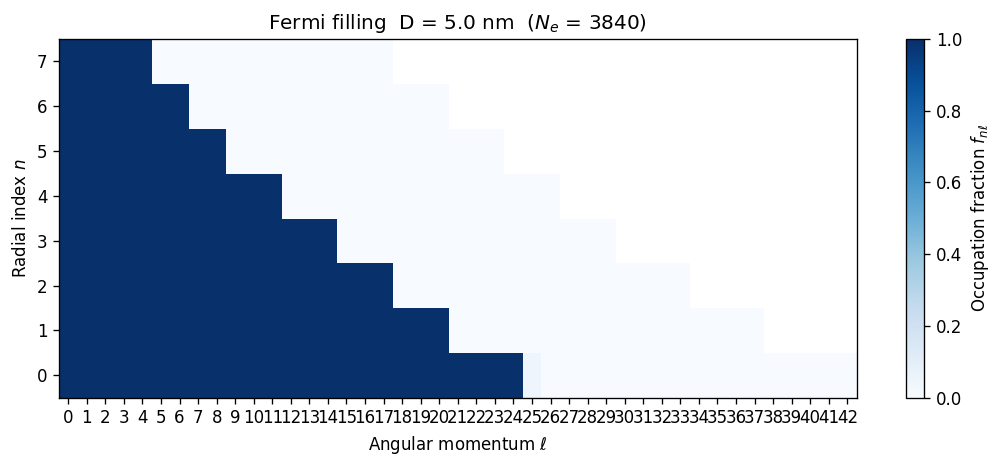

In [6]:
Nmax     = f_occ.shape[1]
plot_N   = min(Nmax, 8)

img = np.full((plot_N, lmax_qw), np.nan)
for l in range(lmax_qw):
    Eb = e_states[l].Eb.real
    for n in range(min(Eb.size, plot_N)):
        img[n, l] = f_occ[l, n]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(img, origin='lower', aspect='auto',
               extent=[-0.5, lmax_qw - 0.5, -0.5, plot_N - 0.5],
               cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label=r'Occupation fraction $f_{n\ell}$')
ax.set_xlabel(r'Angular momentum $\ell$')
ax.set_ylabel('Radial index $n$')
ax.set_title(f'Fermi filling  D = {D} nm  ($N_e$ = {Ne})')
ax.set_xticks(range(lmax_qw))
ax.set_yticks(range(plot_N))
plt.tight_layout()
plt.show()

---
## Step 6 — Diameter sweep

As $D$ grows, more $(n, \ell)$ levels fall below $E_F$ and the level  
spacing shrinks. We track the number of occupied levels and the computed  
Fermi energy versus the bulk reference.

D=  2.0 nm  Ne=   245  occupied levels=  19  EF=6.405 eV
D=  3.0 nm  Ne=   829  occupied levels=  42  EF=6.129 eV
D=  4.0 nm  Ne=  1966  occupied levels=  73  EF=5.959 eV
D=  5.0 nm  Ne=  3840  occupied levels= 115  EF=5.977 eV
D=  6.0 nm  Ne=  6636  occupied levels= 164  EF=5.850 eV
D=  7.0 nm  Ne= 10538  occupied levels= 222  EF=5.777 eV
D=  8.0 nm  Ne= 15730  occupied levels= 292  EF=5.781 eV
D=  9.0 nm  Ne= 22398  occupied levels= 369  EF=5.747 eV
D= 10.0 nm  Ne= 30724  occupied levels= 456  EF=5.722 eV
D= 11.0 nm  Ne= 40894  occupied levels= 549  EF=5.691 eV
D= 12.0 nm  Ne= 53091  occupied levels= 653  EF=5.676 eV
D= 13.0 nm  Ne= 67501  occupied levels= 767  EF=5.679 eV
D= 14.0 nm  Ne= 84307  occupied levels= 890  EF=5.673 eV
D= 15.0 nm  Ne=103694  occupied levels=1022  EF=5.659 eV
D= 16.0 nm  Ne=125846  occupied levels=1161  EF=5.645 eV
D= 17.0 nm  Ne=150948  occupied levels=1310  EF=5.642 eV
D= 18.0 nm  Ne=179184  occupied levels=1467  EF=5.626 eV
D= 19.0 nm  Ne=210738  occupied

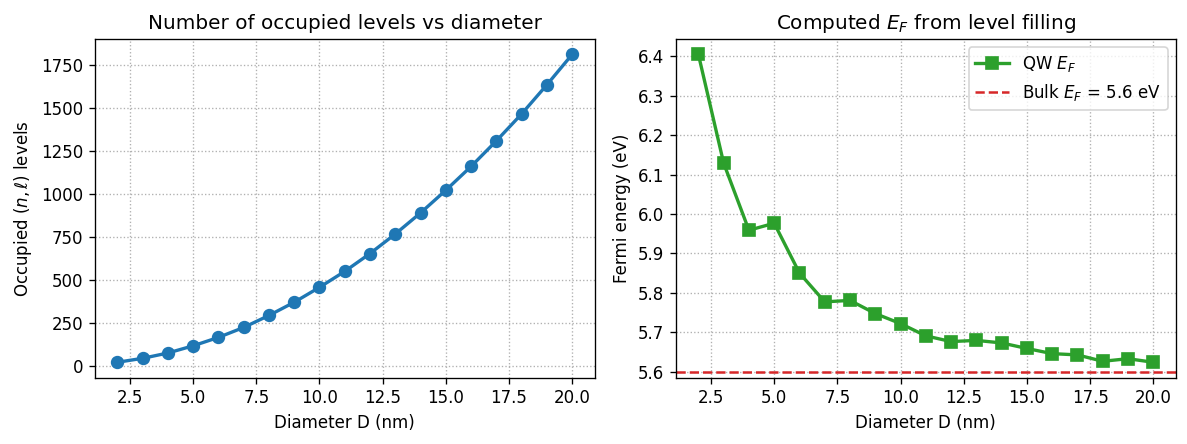

In [10]:
D_values = np.linspace(2.0, 20.0, 19)   # [nm]

n_occ_arr   = []
EF_comp_arr = []
Ne_arr      = []

for Dv in D_values:
    av = Dv / 2
    Em = get_bound_states(av)
    Am = get_normalization(av, Em)
    occ_v, EFv, Ne_v, _ = fill_qw_states_by_energy(Em, Dv, N_atoms_uc, alat_nm)
    n_occ_arr.append(int((occ_v > 0).sum()))
    EF_comp_arr.append(float(EFv))
    Ne_arr.append(int(Ne_v))
    print(f'D={Dv:5.1f} nm  Ne={Ne_v:6d}  occupied levels={int((occ_v>0).sum()):4d}  EF={EFv:.3f} eV')

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.8))

ax0.plot(D_values, n_occ_arr, 'o-', color='C0', lw=2, ms=7)
ax0.set_xlabel('Diameter D (nm)')
ax0.set_ylabel(r'Occupied $(n,\ell)$ levels')
ax0.set_title('Number of occupied levels vs diameter')
ax0.grid(True, ls=':')

ax1.plot(D_values, EF_comp_arr, 's-', color='C2', lw=2, ms=7, label='QW $E_F$')
ax1.axhline(EF, ls='--', color='C3', lw=1.5, label=f'Bulk $E_F$ = {EF} eV')
ax1.set_xlabel('Diameter D (nm)')
ax1.set_ylabel('Fermi energy (eV)')
ax1.set_title('Computed $E_F$ from level filling')
ax1.legend()
ax1.grid(True, ls=':')

plt.tight_layout()
plt.show()

---
## Step 7 — Convenience wrappers

`compute_qw_states` runs the three-step pipeline with a progress bar.  
`compute_qw_states_with_occupations` adds Fermi filling and returns everything in one dict.

In [11]:
result = compute_qw_states_with_occupations(
    a_nm       = a,
    D_nm       = D,
    N_atoms_uc = N_atoms_uc,
    alat_nm    = alat_nm,
)

print('Keys returned:', list(result.keys()))
print(f'Fermi energy  : {result["EF"]:.4f} eV')
print(f'Ne (geometry) : {result["Ne"]}')
print(f'e_states type : {type(result["e_states"][0]).__name__}')
print(f'Shape E_matrix: {result["E_matrix"].shape}')

QW a=2.500:   0%|          | 0/3 [00:00<?, ?step/s]

Keys returned: ['E_matrix', 'A_matrix', 'e_states', 'occ', 'f_occ', 'EF', 'Ne', 'electrons_left']
Fermi energy  : 5.9766 eV
Ne (geometry) : 3840
e_states type : QWLevelSet
Shape E_matrix: (43, 15)


---
## Summary

| Function | Input | Output |
|---|---|---|
| `get_bound_states(a)` | radius $a$ [nm] | $E[\ell, n]$ padded array [eV] |
| `get_normalization(a, E)` | $a$, $E$ matrix | $A[\ell, n]$ real array |
| `e_state_assembly(E, A)` | $E$, $A$ | `list[QWLevelSet]` (`Eb`, `A` per $\ell$) |
| `electrons_per_nanoparticle(D, Nuc, alat)` | geometry | $N_e$ int |
| `fill_qw_states_by_energy(E, D, ...)` | $E$ matrix + geometry | `occ`, $E_F$, $N_e$, leftover |
| `occupation_fraction(occ)` | `occ` | $f \in [0,1]$ per level |
| `compute_qw_states(a)` | $a$ | $(E, A, e\_states)$ |
| `compute_qw_states_with_occupations` | $a$, $D$, geometry | full dict |

### Connection to the hot-carrier pipeline

```
quantum_well.py                       hot_carriers.py
───────────────                       ───────────────
get_bound_states(a)  ─┐
get_normalization(a)  ─┤ -> e_state_assembly  ->  e_states  ->  hot_e_dist(...)
                       │                                         hot_e_dist_spatial(...)
electrons_per_NP  ─────┘
fill_qw_states         ->  EF, occ  (Fermi level for generation threshold)
```